In [2]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(usecwd=True))

# Pick ONE of the providers below by uncommenting the corresponding block.

## --- Google Gemini (free tier OK) ---------------------------------------
# from google import genai
# from google.genai import types
# client   = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
# MODEL    = "gemini-2.5-flash"
# PROVIDER = "gemini"

## --- OpenAI (paid) ------------------------------------------------------
from openai import OpenAI
client   = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
MODEL    = "gpt-4.1-nano-2025-04-14"
PROVIDER = "openai"

print(f"Provider: {PROVIDER}   Model: {MODEL}")

Provider: openai   Model: gpt-4.1-nano-2025-04-14


In [3]:
def chat(prompt, temperature=1.0, max_tokens=200, system=None):
    """Provider-agnostic single-turn completion. Returns response text."""
    if PROVIDER == "gemini":
        r = client.models.generate_content(
            model=MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(
                temperature=temperature,
                max_output_tokens=max_tokens,
                system_instruction=system,
                automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
            ),
        )
        return r.text
    if PROVIDER == "openai":
        msgs = ([{"role": "system", "content": system}] if system else []) + \
               [{"role": "user", "content": prompt}]
        r = client.chat.completions.create(
            model=MODEL, messages=msgs,
            temperature=temperature, max_tokens=max_tokens,
        )
        return r.choices[0].message.content

    raise ValueError(PROVIDER)

# Sanity check
print(chat("Reply with exactly one word: hello", temperature=0, max_tokens=20))

Hello


In [4]:
def create_persona(d):
    """
    Turn a demographics dict into a first-person backstory string.
    d keys: age, gender, race, education, region, income, party, ideology
    """
    return (
        f"I am a {d['age']}-year-old {d['race']} {d['gender']} from the "
        f"{d['region']} United States. My highest level of education is "
        f"{d['education']}. My household income is {d['income']}. "
        f"Politically, I identify as a {d['party']} and describe my views as "
        f"{d['ideology']}."
    )

# Two contrasting personas
persona_a = dict(age=68, gender="man",   race="white", education="high school",
                 region="Southern",  income="$45,000",  party="Republican",
                 ideology="conservative")

persona_b = dict(age=27, gender="woman", race="Black", education="a graduate degree",
                 region="Northeastern", income="$120,000", party="Democrat",
                 ideology="liberal")

print(create_persona(persona_a))
print()
print(create_persona(persona_b))

I am a 68-year-old white man from the Southern United States. My highest level of education is high school. My household income is $45,000. Politically, I identify as a Republican and describe my views as conservative.

I am a 27-year-old Black woman from the Northeastern United States. My highest level of education is a graduate degree. My household income is $120,000. Politically, I identify as a Democrat and describe my views as liberal.


In [5]:
import re, time
from collections import Counter

LIKERT_LABELS = {
    1: "Strongly Disagree", 2: "Disagree", 3: "Neither agree nor disagree",
    4: "Agree",             5: "Strongly Agree",
}

def silicon_sample_likert(demographics, question, scale=(1, 5), temperature=1.0):
    """
    Ask a single silicon respondent one Likert-scale question.

    Returns (int response in [scale[0], scale[1]]) or None if parsing fails.
    """
    persona = create_persona(demographics)
    prompt  = (
        f"{persona}\n\n"
        f"Please answer the following question as this person would.\n\n"
        f"Question: {question}\n\n"
        f"Respond with a single number from {scale[0]} to {scale[1]}, where "
        f"{scale[0]} = Strongly Disagree and {scale[1]} = Strongly Agree. "
        f"Reply with only the number."
    )
    reply = chat(prompt, temperature=temperature, max_tokens=200)
    m = re.search(rf"[{scale[0]}-{scale[1]}]", reply or "")
    return int(m.group()) if m else None

In [6]:
q = "The government should provide universal health care."
print("Persona A (conservative):", silicon_sample_likert(persona_a, q, temperature=0))
print("Persona B (liberal):    ", silicon_sample_likert(persona_b, q, temperature=0))

Persona A (conservative): 2
Persona B (liberal):     5


In [7]:
question = "The government should provide universal health care."

replies = []
for i in range(10):
    r = silicon_sample_likert(persona_b, question, temperature=1.0)
    replies.append(r)
    time.sleep(0.3)       # gentle on the rate limit
print("Ten replies from the SAME liberal persona:", replies)
print("Distribution:", Counter(replies))

Ten replies from the SAME liberal persona: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Distribution: Counter({5: 10})


In [8]:
import itertools, pandas as pd

# 4 personas — 2 (party + ideology) × 2 (age). 
# Education, gender, race, region, income are held fixed
grid = list(itertools.product(
    [("Republican", "conservative"), ("Democrat", "liberal")],
    [28, 68],
))

personas = []
for (party, ideology), age in grid:
    personas.append(dict(
        age=age, gender="woman", race="white", education="a bachelor's degree",
        region="Midwestern", income="$60,000", party=party, ideology=ideology,
    ))

questions = [
    "Stricter gun-control laws would reduce violent crime.",
    "Immigration is generally good for the country's economy.",
]

# 4 personas × 2 questions × 3 replicates = 24 calls
records = []
for pid, p in enumerate(personas):
    for q in questions:
        for rep in range(3):
            ans = silicon_sample_likert(p, q, temperature=1.0)
            records.append({"pid": pid, "party": p["party"], "age": p["age"],
                            "question": q, "rep": rep, "answer": ans})
            time.sleep(0.2)
    print(f"  persona {pid+1}/{len(personas)} done  ({(pid+1)*len(questions)*2} calls)")

panel = pd.DataFrame(records)
panel.head()

  persona 1/4 done  (4 calls)
  persona 2/4 done  (8 calls)
  persona 3/4 done  (12 calls)
  persona 4/4 done  (16 calls)


,pid,party,age,question,rep,answer
0,0,Republican,28,Stricter gun-control laws would reduce violent...,0,2
1,0,Republican,28,Stricter gun-control laws would reduce violent...,1,2
2,0,Republican,28,Stricter gun-control laws would reduce violent...,2,2
3,0,Republican,28,Immigration is generally good for the country'...,0,2
4,0,Republican,28,Immigration is generally good for the country'...,1,3


In [9]:
by_party = (panel
    .groupby(["question", "party"])["answer"]
    .agg(["mean", "std", "count"])
    .round(2))
print(by_party)

                                                               mean   std  \
question                                           party                    
Immigration is generally good for the country's... Democrat    4.00  0.00   
                                                   Republican  2.17  0.41   
Stricter gun-control laws would reduce violent ... Democrat    4.00  0.00   
                                                   Republican  2.00  0.00   

                                                               count  
question                                           party              
Immigration is generally good for the country's... Democrat        6  
                                                   Republican      6  
Stricter gun-control laws would reduce violent ... Democrat        6  
                                                   Republican      6  


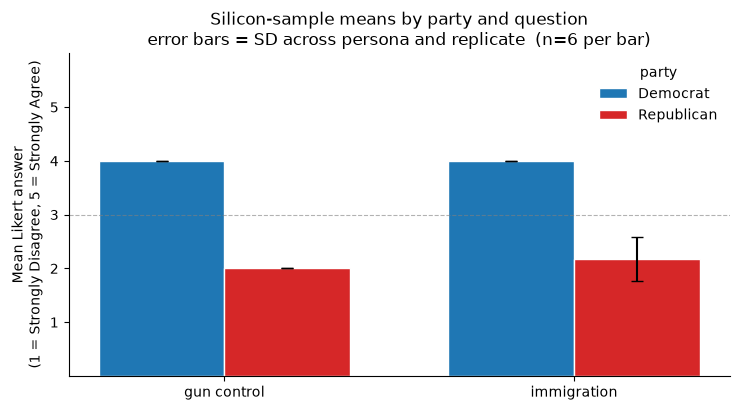

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Short x-axis labels for readability
short = {
    "Stricter gun-control laws would reduce violent crime.":      "gun control",
    "Immigration is generally good for the country's economy.":   "immigration",
}

agg = (panel
       .groupby(["question", "party"])["answer"]
       .agg(mean="mean", std="std")
       .reset_index())
agg["q_short"] = agg["question"].map(short)

qs      = list(short.values())
parties = ["Democrat", "Republican"]
colors  = {"Democrat": "#1f77b4", "Republican": "#d62728"}
x       = np.arange(len(qs))
width   = 0.36

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, party in enumerate(parties):
    sub = agg[agg["party"] == party].set_index("q_short").reindex(qs)
    ax.bar(x + (i - 0.5) * width, sub["mean"], width,
           yerr=sub["std"].fillna(0), capsize=4,
           label=party, color=colors[party], edgecolor="white")

ax.axhline(3, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)   # neutral line
ax.set_xticks(x); ax.set_xticklabels(qs)
ax.set_ylim(0, 6); ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylabel("Mean Likert answer\n(1 = Strongly Disagree, 5 = Strongly Agree)")
ax.set_title("Silicon-sample means by party and question\n"
             "error bars = SD across persona and replicate  (n=6 per bar)")
ax.legend(frameon=False, title="party")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
TOPIC   = "increasing immigration to the United States"
POSITION_PROMPT = f"Do you support {TOPIC}? (yes/no)"
REASON_PROMPT   = "In one or two sentences, why?"

# Suppose we have a respondent's answers already:
respondent = {
    "position": "no",
    "reason":   "I'm worried it will push down wages for people already here.",
}

def tailored_counterargument(respondent, topic=TOPIC):
    system = (
        "You are a careful, respectful writer. Given a survey respondent's "
        "position on a policy and their stated reason, write a short (60-80 "
        "word) counter-argument that directly addresses THEIR specific reason. "
        "Do not be dismissive. Do not repeat their reason back to them. "
        "Present at most one concrete piece of evidence."
    )
    user = (
        f"Topic: {topic}\n"
        f"Respondent's position: {respondent['position']}\n"
        f"Respondent's reason: {respondent['reason']}\n\n"
        f"Write the counter-argument."
    )
    return chat(user, system=system, temperature=0.7, max_tokens=250)

print(tailored_counterargument(respondent))

Research indicates that immigration can actually boost overall economic growth, which often leads to more job opportunities and higher wages for native workers over time. For example, a 2017 study by the National Academies of Sciences found that increased immigration does not significantly lower wages for native-born workers and can sometimes benefit them by expanding the economy. This suggests that concerns about wage suppression may be less justified than the potential economic benefits of welcoming more immigrants.


In [12]:
agent_A = dict(
    name="Alex",
    profile="A 55-year-old retired coal miner from West Virginia. Deeply skeptical "
            "of climate policy — believes it has cost his community jobs. Cares "
            "about his grandchildren's future, values plain speech, distrusts experts.",
)

agent_B = dict(
    name="Priya",
    profile="A 32-year-old climate scientist at a public university. Grew up in "
            "coastal Bangladesh, saw flooding worsen through her childhood. "
            "Believes urgency is warranted but empathetic to displaced workers.",
)

TOPIC = ("The federal government should invest heavily in transitioning away "
         "from coal-fired power plants.")

def agent_turn(agent, transcript, topic):
    system = (
        f"You are role-playing a character in a conversation. Stay in character. "
        f"Character profile:\n{agent['profile']}\n\n"
        f"Respond in ONE short paragraph (2-3 sentences). Do not repeat what has "
        f"already been said. Do not narrate stage directions. Just speak."
    )
    user = (
        f"Topic under discussion: {topic}\n\n"
        f"Conversation so far:\n{transcript if transcript else '(the conversation is just starting)'}\n\n"
        f"Your next line, as {agent['name']}:"
    )
    return chat(user, system=system, temperature=0.9, max_tokens=200).strip()

transcript = ""
speakers   = [agent_A, agent_B]
for turn in range(6):                           # 6 turns total, alternating
    speaker = speakers[turn % 2]
    line    = agent_turn(speaker, transcript, TOPIC)
    print(f"\n[{speaker['name']}] {line}")
    transcript += f"\n{speaker['name']}: {line}"

print("\n\n--- FULL TRANSCRIPT ---")
print(transcript)


[Alex] Look, I got grandkids too, but these fancy plans ain’t gonna bring jobs back, just push us further into poverty. I say let’s stick with what works and fix what we got instead of chasing some pipe dream of a cleaner world that won’t even be clean.

[Priya] I understand your concerns, Alex, but investing in renewable energy can create new jobs and economic opportunities while reducing our reliance on coal, which is devastating for both our health and climate. We don’t have the luxury to wait; the longer we delay, the worse the impacts become for future generations, especially vulnerable communities like ours.

[Alex] I just don’t buy it—those new jobs are always elsewhere, and by the time they come, our old ones are gone for good. You think those big city folks know what it’s like out here in the dirt; they don’t care about us, just their fancy climate goals.

[Priya] I hear you, Alex, and I truly want to see your community thrive. Transitioning away from coal can be done thought